# GFS

In [1]:
from herbie.v2 import GFS

In [2]:
H = GFS('2026-01-01')
H

,Name,Type,URL,Index
,aws,GRIB2,https://noaa-gfs-bdp-pds.s3.amazonaws.com/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000,.idx
,nomads,GRIB2,https://nomads.ncep.noaa.gov/pub/data/nccf/com/gfs/prod/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000,.idx
,ftpprd,GRIB2,https://ftpprd.ncep.noaa.gov/data/nccf/com/gfs/prod/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000,.idx
,google,GRIB2,https://storage.googleapis.com/global-forecast-system/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000,.idx
,azure,GRIB2,https://noaagfs.blob.core.windows.net/gfs/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000,.idx
,ncar_rda,GRIB2,https://data.rda.ucar.edu/d084001/2026/20260101/gfs.0p25.2026010100.f000.grib2,.idx


In [ ]:
H.inventory("GRD:10 m above")

grib_message,start_byte,end_byte,reference_time,source,variable,level,forecast_time
i64,i64,i64,datetime[μs],str,str,str,str
585,421153101,422123815,2026-01-01 00:00:00,"""https://noaa-gfs-bdp-pds.s3.am…","""UGRD""","""10 m above ground""","""anl"""
586,422123816,423071353,2026-01-01 00:00:00,"""https://noaa-gfs-bdp-pds.s3.am…","""VGRD""","""10 m above ground""","""anl"""


In [6]:
ds = H.xarray("GRD:10 m above")
ds

Downloading subset (2 messages, 1 groups) from  → gfs.t00z.pgrb2.0p25.f000__subset-25fb7665

/home/blaylock/GITHUB/Herbie/.venv/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

✓ Done (1.5s) → /home/blaylock/herbie-data/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000__subset-25fb7665

/home/blaylock/GITHUB/Herbie/.venv/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


<xarray.Dataset> Size: 8MB
Dimensions:              (latitude: 721, longitude: 1440)
Coordinates:
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude            (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
    time                 datetime64[ns] 8B 2026-01-01
    step                 timedelta64[ns] 8B 00:00:00
    heightAboveGround    float64 8B 10.0
    valid_time           datetime64[ns] 8B 2026-01-01
    gribfile_projection  object 8B None
Data variables:
    u10                  (latitude, longitude) float32 4MB 1.884 ... -1.846
    v10                  (latitude, longitude) float32 4MB -5.397 ... -1.907
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

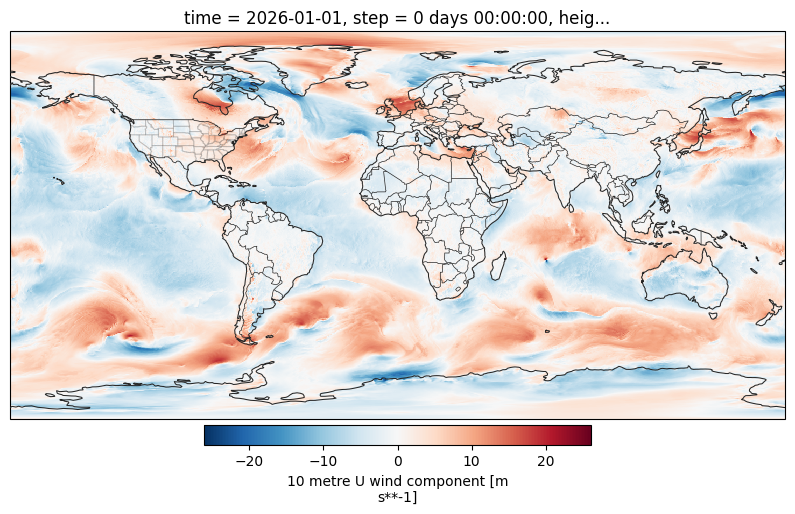

In [7]:
from herbie.toolbox import EasyMap, pc

# Create Cartopy Map
ax = EasyMap(figsize=(10, 8), crs=ds.herbie.crs).STATES().BORDERS().ax

# Plot data on map

ds.u10.plot(
    ax=ax,
    x="longitude",
    y="latitude",
    transform=pc,
    cbar_kwargs=dict(pad=0.01, shrink=0.5, orientation="horizontal"),
)


In [8]:
import numpy as np

ds["wind_speed_10m"] = np.sqrt(ds.u10**2 + ds.v10**2)
ds

<xarray.Dataset> Size: 12MB
Dimensions:              (latitude: 721, longitude: 1440)
Coordinates:
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude            (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
    time                 datetime64[ns] 8B 2026-01-01
    step                 timedelta64[ns] 8B 00:00:00
    heightAboveGround    float64 8B 10.0
    valid_time           datetime64[ns] 8B 2026-01-01
    gribfile_projection  object 8B None
Data variables:
    u10                  (latitude, longitude) float32 4MB 1.884 ... -1.846
    v10                  (latitude, longitude) float32 4MB -5.397 ... -1.907
    wind_speed_10m       (latitude, longitude) float32 4MB 5.716 5.716 ... 2.655
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

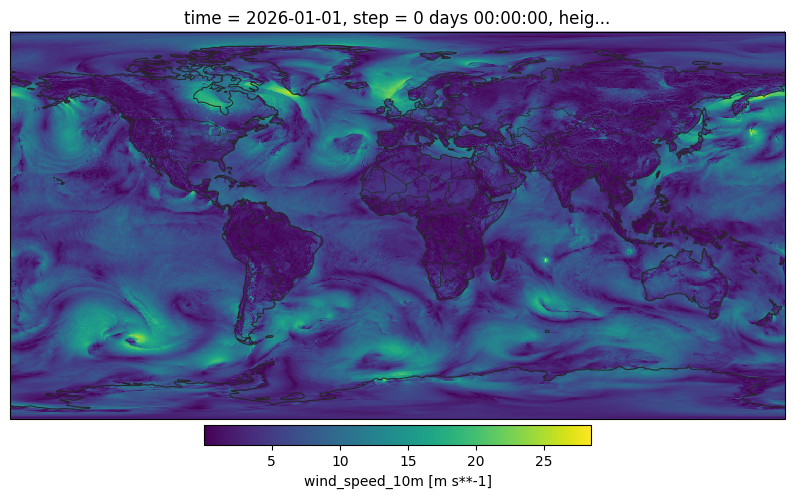

In [9]:
from herbie.toolbox import EasyMap, pc

# Create Cartopy Map
ax = EasyMap(figsize=(10, 8), crs=ds.herbie.crs).STATES().BORDERS().ax

# Plot data on map

ds.wind_speed_10m.plot(
    ax=ax,
    x="longitude",
    y="latitude",
    transform=pc,
    cbar_kwargs=dict(pad=0.01, shrink=0.5, orientation="horizontal"),
)
